GD Time: 0.0343012809753418
Normal Equation Time: 0.00013327598571777344
Normal Equation MSE: 60451409.832681656


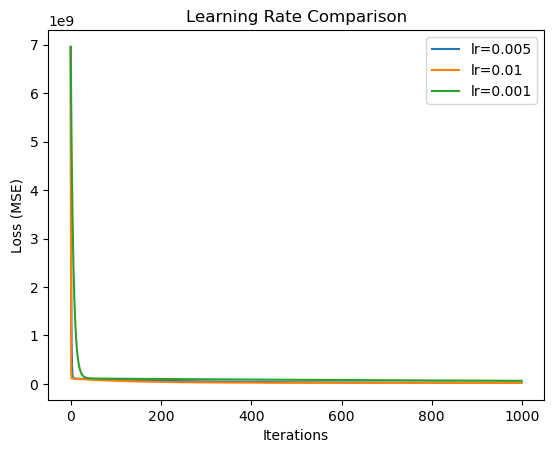

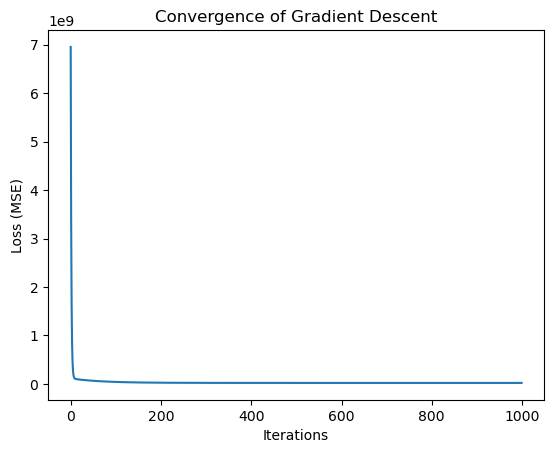

MAE:  6673.572235831898
MSE:  60451409.832681045
R2:  0.904128890392985


In [41]:
#import dependencies
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split as tts
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#creating the LR object
class Linear_Regression:

    def __init__(self, learning_rate, no_of_iterations): #Initation function
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations

    def fit(self,X, Y): #used to train the LR with the dataset
        
        #number of training examples(m) and number of features of the dataset(n)
        
        self.m, self.n=X.shape #n is the number of rows and cols, cols represent the 1 feature

        #initialize w and b to zeros
        self.w = np.zeros(self.n)
        self.b=0
        self.X=X
        self.Y=Y

        self.loss_history = []
        
        #implementing Gradient Decesent 
        for i in range(self.no_of_iterations):
            Y_prediction = self.predict(self.X)
            self.update_weights()
            
            # COMPUTE LOSS (MSE)
            loss = np.mean((self.Y - Y_prediction) ** 2)
            self.loss_history.append(loss)

       
    def update_weights(self): #used to update the weight(comes under gradient decesent)
        Y_prediction = self.predict(self.X)
        
        #calculate dw and db
        dw = -(2*(self.X.T).dot(self.Y - Y_prediction))/self.m
        db = -2*np.sum(self.Y - Y_prediction)/self.m

        #calculate w and b
        self.w = self.w - self.learning_rate*dw
        self.b = self.b - self.learning_rate*db
        
    def predict(self, X): #used to predict ouput with the given dataset
        return X.dot(self.w)+self.b
        
    #using Linear Regression model to predict

#data pre-processing
#load csv data
df=pd.read_csv("datasets/salary_data.csv")

from sklearn.preprocessing import StandardScaler

# 1. Create scalers
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# 2. Scale X
x_train = x_scaler.fit_transform(x_train)
x_test = x_scaler.transform(x_test)

# 3. Scale Y BEFORE training
y_train = y_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_test = y_scaler.transform(y_test.reshape(-1,1)).flatten()

# 4. Train model on SCALED data
model = Linear_Regression(0.02, 1000)
model.fit(x_train, y_train)

# 5. Predict (this is now scaled prediction)
y_pred_scaled = model.predict(x_test)

# 6. Convert back to original scale
y_pred_actual = y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

X = df.iloc[:,:-1].values
Y = df.iloc[:,1].values

#splitting data for training and testing
x_train, x_test, y_train, y_test = tts(X,Y,test_size=0.33, random_state=2)

# Train models with different learning rates
model1 = Linear_Regression(0.005, 1000)
model2 = Linear_Regression(0.01, 1000)
model3 = Linear_Regression(0.001, 1000)

model1.fit(x_train, y_train) 
model2.fit(x_train, y_train)
model3.fit(x_train, y_train)

#
X_b = np.c_[np.ones((x_train.shape[0], 1)), x_train]
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_train)
b_normal = theta[0]
w_normal = theta[1:]
X_test_b = np.c_[np.ones((x_test.shape[0], 1)), x_test]
y_pred_normal = X_test_b.dot(theta)
mse_normal = mean_squared_error(y_test, y_pred_normal)

import time
# Gradient Descent time
start = time.time()
model.fit(x_train, y_train)
end = time.time()
gd_time = end - start

# Normal Equation time
start = time.time()
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_train)
end = time.time()
ne_time = end - start

print("GD Time:", gd_time)
print("Normal Equation Time:", ne_time)
print("Normal Equation MSE:", mse_normal)

# Plot convergence comparison
plt.plot(model1.loss_history, label="lr=0.005")
plt.plot(model2.loss_history, label="lr=0.01")
plt.plot(model3.loss_history, label="lr=0.001")


plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

#training the LR model
model=Linear_Regression(learning_rate=0.02, no_of_iterations=1000)
model.fit(x_train, y_train)

#convergence graph
plt.plot(model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Convergence of Gradient Descent")
plt.show()

test_data_prediction = model.predict(x_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred_actual)
mse= mean_squared_error(y_test, y_pred_actual)
r2 = r2_score(y_test, test_data_prediction)
print("MAE: ", mae)
print("MSE: ", mse)
print("R2: ", r2)